# Recommendation systems

## Importación de librerías y paquetes y definición de constantes

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split para modelado
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# Métricas
from sklearn.metrics import confusion_matrix, recall_score, classification_report
from utils import get_classifier_metrics
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings

In [279]:
warnings.filterwarnings("ignore")

## Recopilación de datos

In [280]:
df = pd.read_csv("../data/raw/adult-census-income.csv")
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [281]:
df.duplicated().sum()

24

In [282]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(32537, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [283]:
df.replace('?', np.nan, inplace=True)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [284]:
df.isnull().sum().sort_values(ascending=False) / len(df)

occupation        0.056643
workclass         0.056428
native.country    0.017887
age               0.000000
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
income            0.000000
dtype: float64

In [285]:
df.groupby('education')['education.num'].mean().sort_values(ascending=False)

education
Doctorate       16.0
Prof-school     15.0
Masters         14.0
Bachelors       13.0
Assoc-acdm      12.0
Assoc-voc       11.0
Some-college    10.0
HS-grad          9.0
12th             8.0
11th             7.0
10th             6.0
9th              5.0
7th-8th          4.0
5th-6th          3.0
1st-4th          2.0
Preschool        1.0
Name: education.num, dtype: float64

### Convertimos los valores raros en nulos para poder contabilizarlos y eliminarlos

In [286]:
df.dropna(inplace=True)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


### Seleccionamos las variables más importantes para armar nuestro sistema de recomendación

In [287]:
df_final = df[['education.num', 'occupation', 'workclass', 'relationship', 'age', 
               'hours.per.week', 'sex', 'marital.status', 'income']]

In [288]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 1 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   education.num   30139 non-null  int64 
 1   occupation      30139 non-null  object
 2   workclass       30139 non-null  object
 3   relationship    30139 non-null  object
 4   age             30139 non-null  int64 
 5   hours.per.week  30139 non-null  int64 
 6   sex             30139 non-null  object
 7   marital.status  30139 non-null  object
 8   income          30139 non-null  object
dtypes: int64(3), object(6)
memory usage: 2.3+ MB


## Split de datos

In [289]:
X = df_final.drop(['income'], axis=1)
y = (df_final['income'] == '>50K').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,education.num,occupation,workclass,relationship,age,hours.per.week,sex,marital.status
16877,12,Sales,Private,Husband,46,50,Male,Married-civ-spouse
29858,9,Handlers-cleaners,Private,Other-relative,28,60,Male,Never-married
29038,2,Priv-house-serv,Private,Other-relative,54,40,Female,Separated
31773,9,Adm-clerical,Federal-gov,Own-child,41,40,Male,Never-married
14714,9,Transport-moving,Private,Husband,36,50,Male,Married-civ-spouse
...,...,...,...,...,...,...,...,...
21410,9,Craft-repair,Private,Not-in-family,43,45,Male,Never-married
26887,12,Adm-clerical,Private,Not-in-family,33,40,Female,Never-married
15668,7,Handlers-cleaners,Private,Not-in-family,34,43,Male,Divorced
948,9,Tech-support,Private,Husband,50,40,Male,Married-civ-spouse


In [290]:
y

1        0
3        0
4        0
5        0
6        0
        ..
32556    0
32557    0
32558    1
32559    0
32560    0
Name: income, Length: 30139, dtype: int32

In [291]:
y.value_counts(normalize=True)

income
0    0.750954
1    0.249046
Name: proportion, dtype: float64

## Scaling & Encoding

In [292]:
X_train_num = X_train.select_dtypes(include=['int32', 'int64'])
X_test_num = X_test.select_dtypes(include=['int32', 'int64'])

### Encoding con OneHotEncoder

In [293]:
cat_variables = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
one_hot_encoder = OneHotEncoder(sparse_output=False)
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_train_cat_ohe

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,...,relationship_Wife,sex_Female,sex_Male,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
16877,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
29858,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
29038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31773,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21410,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26887,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15668,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [294]:
X_test_cat_ohe = one_hot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,...,relationship_Wife,sex_Female,sex_Male,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
15088,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
24423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
20310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14750,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
20873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
31146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
27772,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [295]:
X_train = pd.concat([X_train_num, X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test_num, X_test_cat_ohe], axis=1)
X_train

,education.num,age,hours.per.week,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,...,relationship_Wife,sex_Female,sex_Male,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
16877,12,46,50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
29858,9,28,60,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
29038,2,54,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31773,9,41,40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14714,9,36,50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21410,9,43,45,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26887,12,33,40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15668,7,34,43,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
948,9,50,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [296]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24111 entries, 16877 to 13705
Data columns (total 39 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   education.num                         24111 non-null  int64  
 1   age                                   24111 non-null  int64  
 2   hours.per.week                        24111 non-null  int64  
 3   occupation_Adm-clerical               24111 non-null  float64
 4   occupation_Armed-Forces               24111 non-null  float64
 5   occupation_Craft-repair               24111 non-null  float64
 6   occupation_Exec-managerial            24111 non-null  float64
 7   occupation_Farming-fishing            24111 non-null  float64
 8   occupation_Handlers-cleaners          24111 non-null  float64
 9   occupation_Machine-op-inspct          24111 non-null  float64
 10  occupation_Other-service              24111 non-null  float64
 11  occupation_Priv-

## Modelado con Random Forest

In [297]:
model_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=24)

In [298]:
model_rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [299]:
y_pred_test = model_rf.predict(X_test)
y_pred_train = model_rf.predict(X_train)
y_pred_test

array([0, 0, 0, ..., 1, 0, 0])

In [300]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.956908,0.956908,0.956908,0.956908
Test set,0.814532,0.814532,0.814532,0.814532


In [301]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4561
           1       0.63      0.59      0.61      1467

    accuracy                           0.81      6028
   macro avg       0.75      0.74      0.74      6028
weighted avg       0.81      0.81      0.81      6028



## Sistema de recomendación

### Recomendación por horas de trabajo

In [ ]:
perfil_usuario = df_final[df_final['income'] == '<=50K'].iloc[0]
perfil_usuario

education.num                     12
occupation              Craft-repair
workclass               Self-emp-inc
relationship                 Husband
age                               40
hours.per.week                    50
sex                             Male
marital.status    Married-civ-spouse
income                         <=50K
Name: 135, dtype: object

In [318]:
perfil_cod =  X_train.loc[perfil_usuario.name].copy()
perfil_cod

education.num                           12.0
age                                     40.0
hours.per.week                          50.0
occupation_Adm-clerical                  0.0
occupation_Armed-Forces                  0.0
occupation_Craft-repair                  1.0
occupation_Exec-managerial               0.0
occupation_Farming-fishing               0.0
occupation_Handlers-cleaners             0.0
occupation_Machine-op-inspct             0.0
occupation_Other-service                 0.0
occupation_Priv-house-serv               0.0
occupation_Prof-specialty                0.0
occupation_Protective-serv               0.0
occupation_Sales                         0.0
occupation_Tech-support                  0.0
occupation_Transport-moving              0.0
workclass_Federal-gov                    0.0
workclass_Local-gov                      0.0
workclass_Private                        0.0
workclass_Self-emp-inc                   1.0
workclass_Self-emp-not-inc               0.0
workclass_

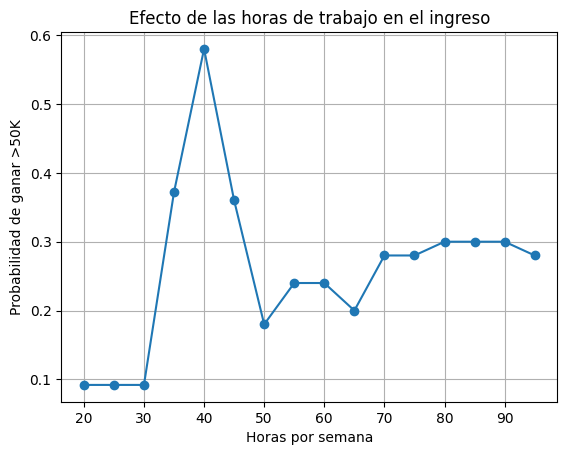

In [319]:
# Guardamos los resultados
horas = []
probabilidades = []

for h in range(20, 100, 5):
    perfil_simulado = perfil_cod.copy()
    perfil_simulado['hours.per.week'] = h
    proba = model_rf.predict_proba([perfil_simulado])[0][1]
    horas.append(h)
    probabilidades.append(proba)

# Graficar
plt.plot(horas, probabilidades, marker='o')
plt.xlabel('Horas por semana')
plt.ylabel('Probabilidad de ganar >50K')
plt.title('Efecto de las horas de trabajo en el ingreso')
plt.grid()
plt.show()

### Recomendación por ocupación

In [ ]:
perfil_base = df_final[df_final['income'] == '<=50K'].iloc[0]
num_cols = df_final.select_dtypes(include=['int32', 'int64']).columns.tolist()
cat_cols = ['occupation', 'workclass', 'relationship', 'sex', 'marital.status']

In [324]:

resultados = []

for ocupacion in df_final['occupation'].unique():
    perfil_mod = perfil_base.copy()
    perfil_mod['occupation'] = ocupacion

    # 1. Crear un DataFrame con una sola fila
    perfil_df = pd.DataFrame([perfil_mod])

    # 2. Separar en variables categóricas y numéricas
    perfil_cat = perfil_df[cat_cols]
    perfil_num = perfil_df[num_cols]

    # 3. Codificar categorías con el mismo OneHotEncoder
    perfil_cat_enc = one_hot_encoder.transform(perfil_cat)

    # 4. Combinar con las numéricas
    perfil_final = np.hstack([perfil_num, perfil_cat_enc])

    # 5. Predecir con el modelo
    proba = model_rf.predict_proba(perfil_final)[0][1]
    resultados.append((ocupacion, proba))



In [325]:
resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)

for ocup, p in resultados_ordenados[:5]:
    print(f"{ocup:25s} → Prob. >50K: {p:.2%}")

Sales                     → Prob. >50K: 100.00%
Exec-managerial           → Prob. >50K: 80.00%
Transport-moving          → Prob. >50K: 76.00%
Armed-Forces              → Prob. >50K: 56.00%
Tech-support              → Prob. >50K: 55.20%
